## UK House Prices
### Notebook 1

Source
https://www.gov.uk/government/statistical-data-sets/uk-house-price-index-data-downloads-december-

Information on dataset
https://www.gov.uk/government/publications/about-the-uk-house-price-index/about-the-uk-house-price-index#data-tables


1. Import house prices dataset
2. Initial data inspection
3. Clean Data
4. EDA

   

In [55]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns

### 1. Import house prices dataset

In [56]:
filepath = "../data/UK-HPI-full-file-2025-12.csv"

#### Create a dataframe from csv

In [57]:
data = pd.read_csv(filepath)

### 2. Initial data inspection

#### Examine data

In [58]:
print(f"Data shape:{data.shape}")
data.head()

Data shape:(149085, 54)


,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0


In [59]:
data.describe()

,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,DetachedPrice,DetachedIndex,Detached1m%Change,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
count,1.490850e+05,149085.000000,5244.000000,148632.000000,144225.000000,5244.000000,144618.000000,1.422840e+05,142284.000000,141889.000000,...,1.416640e+05,141664.000000,141268.000000,136936.000000,138483.000000,1.418680e+05,141868.000000,141472.000000,137140.000000,141858.000000
mean,1.831012e+05,59.835763,62.132113,0.526866,6.100826,168752.656941,1252.600105,3.420380e+05,59.933395,0.461848,...,2.196692e+05,61.681981,0.497958,6.245756,135.956161,1.847985e+05,60.045649,0.472946,6.054274,1138.200045
std,1.311841e+05,26.619737,25.039764,1.934405,8.622357,94882.354669,7707.191260,3.432452e+05,25.206280,1.697813,...,1.342548e+05,26.401143,1.751680,7.974581,843.840990,1.310111e+05,25.507217,1.730925,8.408653,6965.933714
min,2.553000e+03,0.800000,13.900000,-30.300000,-35.800000,39008.000000,2.000000,4.011700e+04,9.400000,-19.600000,...,2.244300e+04,8.000000,-29.800000,-28.900000,1.000000,2.271600e+04,9.000000,-30.600000,-30.300000,2.000000
25%,1.005410e+05,38.200000,46.600000,-0.500000,1.100000,116135.000000,140.000000,1.785228e+05,41.200000,-0.500000,...,1.279912e+05,42.400000,-0.500000,1.700000,10.000000,1.021160e+05,40.900000,-0.500000,1.000000,126.000000
50%,1.547560e+05,61.000000,62.600000,0.500000,5.100000,153018.500000,215.000000,2.603840e+05,60.000000,0.400000,...,1.982200e+05,61.600000,0.500000,5.400000,21.000000,1.549365e+05,60.800000,0.500000,5.100000,193.000000
75%,2.301380e+05,80.300000,80.400000,1.400000,10.100000,209241.750000,376.000000,3.961765e+05,79.800000,1.400000,...,2.780390e+05,82.800000,1.500000,10.100000,46.000000,2.312262e+05,79.600000,1.400000,10.200000,343.000000
max,1.656986e+06,153.100000,110.000000,35.300000,98.400000,574627.000000,183609.000000,5.820174e+06,147.000000,34.800000,...,1.414204e+06,149.600000,34.900000,96.200000,21097.000000,1.665089e+06,152.700000,35.600000,98.600000,166098.000000


#### Review missing variables


In [60]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 149085 entries, 0 to 149084
Data columns (total 54 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    149085 non-null  str    
 1   RegionName              149085 non-null  str    
 2   AreaCode                149085 non-null  str    
 3   AveragePrice            149085 non-null  int64  
 4   Index                   149085 non-null  float64
 5   IndexSA                 5244 non-null    float64
 6   1m%Change               148632 non-null  float64
 7   12m%Change              144225 non-null  float64
 8   AveragePriceSA          5244 non-null    float64
 9   SalesVolume             144618 non-null  float64
 10  DetachedPrice           142284 non-null  float64
 11  DetachedIndex           142284 non-null  float64
 12  Detached1m%Change       141889 non-null  float64
 13  Detached12m%Change      137568 non-null  float64
 14  SemiDetachedPrice       142284 

We can see there are 53 columns, and a lot have missing values. We will reduce some of these features down.
Some of these variables are essentially the same - Average Price, Index, IndexSA and AveragePrice SA, but let's inspect the index to see how it is implemented.

In [61]:
data.groupby('RegionName')['Index'].describe().sort_values(by='max',ascending=False)

,count,mean,std,min,25%,50%,75%,max
RegionName,,,,,,,,
City of Aberdeen,264.0,114.121591,20.735505,55.1,103.950,117.60,126.125,153.1
Ards and North Down,252.0,87.740476,19.193993,62.2,73.150,81.50,101.325,140.5
Mid Ulster,252.0,85.641667,19.480325,55.7,71.300,81.00,100.250,137.2
Armagh City Banbridge and Craigavon,252.0,83.413095,19.761751,54.7,69.450,78.00,97.975,137.1
Belfast,252.0,85.039286,18.872139,55.5,70.900,81.65,99.550,134.8
...,...,...,...,...,...,...,...,...
Sutton,372.0,56.766667,26.220627,15.4,38.200,52.10,82.900,100.0
Croydon,372.0,57.647849,26.250962,16.0,39.275,52.30,86.825,100.0
Thanet,372.0,51.231183,25.236037,12.7,31.850,48.20,73.375,100.0


So we can see all seem to start at different indexes, and City of Aberdeen seems to contain the highest. Indexes are set for individual counties at some point, and are changed from that original zero index.

Variables such as 1m% change and 12m% change are encoding growth.

Then there is segmented market data; splitting into type of property; detached, semi-detached, flat, purchase type; mortgage, cash, buyer type and age (new/old). We will drop the segmented market data, to focus on modelling across these segments.

### 3. Clean data
### Drop variables not required

So we will keep 'Date', 'RegionName', 'AreaCode', 'AveragePrice', 'Index', '1m%Change', '12m%Change', 'SalesVolume'. 

In [62]:
data = data[['Date','RegionName','AreaCode','AveragePrice','Index','1m%Change','12m%Change','SalesVolume']]

### Check duplicate data

In [63]:
data.duplicated().sum()

np.int64(0)

### Clean dates

In [64]:
# inspect dates
print(data.groupby('RegionName')['Date'].unique())

# check datetime format
print(type(data['Date'].iloc[0]))

RegionName
Aberdeenshire               [01/01/2004, 01/02/2004, 01/03/2004, 01/04/200...
Adur                        [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Amber Valley                [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Angus                       [01/01/2004, 01/02/2004, 01/03/2004, 01/04/200...
Antrim and Newtownabbey     [01/01/2005, 01/02/2005, 01/03/2005, 01/04/200...
                                                  ...                        
Wychavon                    [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Wyre                        [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Wyre Forest                 [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
York                        [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Yorkshire and The Humber    [01/04/1968, 01/05/1968, 01/06/1968, 01/07/196...
Name: Date, Length: 405, dtype: object
<class 'str'>


There seems to be some variation in dates across the data, let's convert to datetime and inspect missing values.

In [65]:
data['Date'] = pd.to_datetime(
    data['Date'].astype(str).str.strip(),
    format='%d/%m/%Y',
    errors='raise'
)

In [66]:
# check formatting
data['Date'].tail(10).apply(lambda x: (x, x.day, x.month))

149075     (2025-03-01 00:00:00, 1, 3)
149076     (2025-04-01 00:00:00, 1, 4)
149077     (2025-05-01 00:00:00, 1, 5)
149078     (2025-06-01 00:00:00, 1, 6)
149079     (2025-07-01 00:00:00, 1, 7)
149080     (2025-08-01 00:00:00, 1, 8)
149081     (2025-09-01 00:00:00, 1, 9)
149082    (2025-10-01 00:00:00, 1, 10)
149083    (2025-11-01 00:00:00, 1, 11)
149084    (2025-12-01 00:00:00, 1, 12)
Name: Date, dtype: object

In [67]:
data.sort_values(by=['RegionName','Date'])

,Date,RegionName,AreaCode,AveragePrice,Index,1m%Change,12m%Change,SalesVolume
0,2004-01-01,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,388.0
1,2004-02-01,Aberdeenshire,S12000034,84623,41.1,0.0,NaN,326.0
2,2004-03-01,Aberdeenshire,S12000034,86536,42.1,2.3,NaN,453.0
3,2004-04-01,Aberdeenshire,S12000034,87373,42.5,1.0,NaN,571.0
4,2004-05-01,Aberdeenshire,S12000034,89493,43.5,2.4,NaN,502.0
...,...,...,...,...,...,...,...,...
149080,2025-08-01,Yorkshire and The Humber,E12000003,206107,107.6,0.9,2.0,5471.0
149081,2025-09-01,Yorkshire and The Humber,E12000003,206581,107.8,0.2,3.9,4745.0
149082,2025-10-01,Yorkshire and The Humber,E12000003,206401,107.7,-0.1,3.2,4961.0
149083,2025-11-01,Yorkshire and The Humber,E12000003,209467,109.3,1.5,3.8,NaN


### Missing data

In [68]:
data.isna().sum()

Date               0
RegionName         0
AreaCode           0
AveragePrice       0
Index              0
1m%Change        453
12m%Change      4860
SalesVolume     4467
dtype: int64

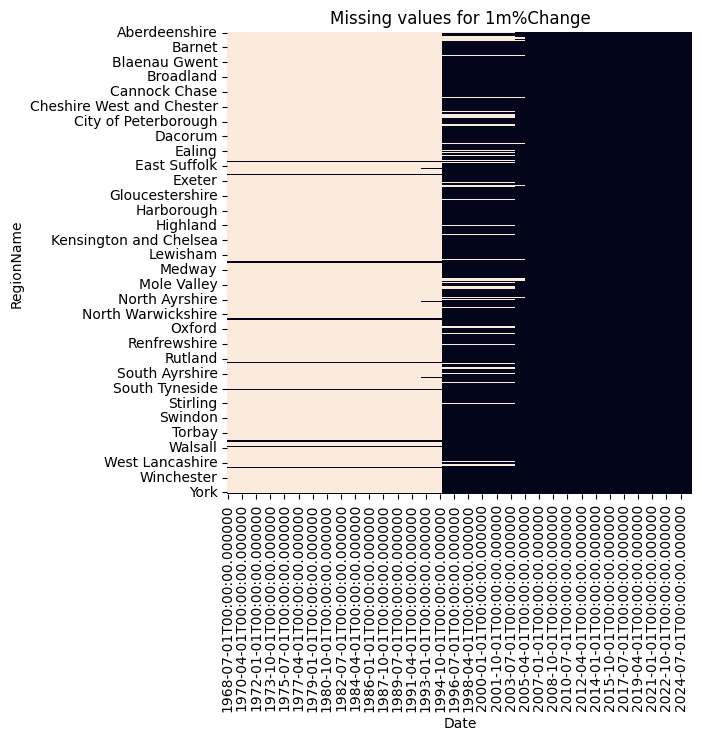

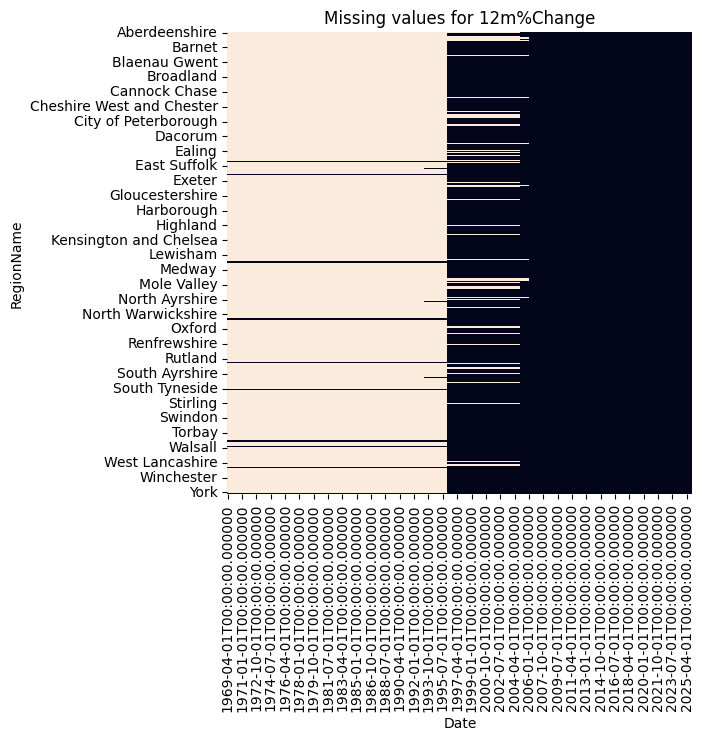

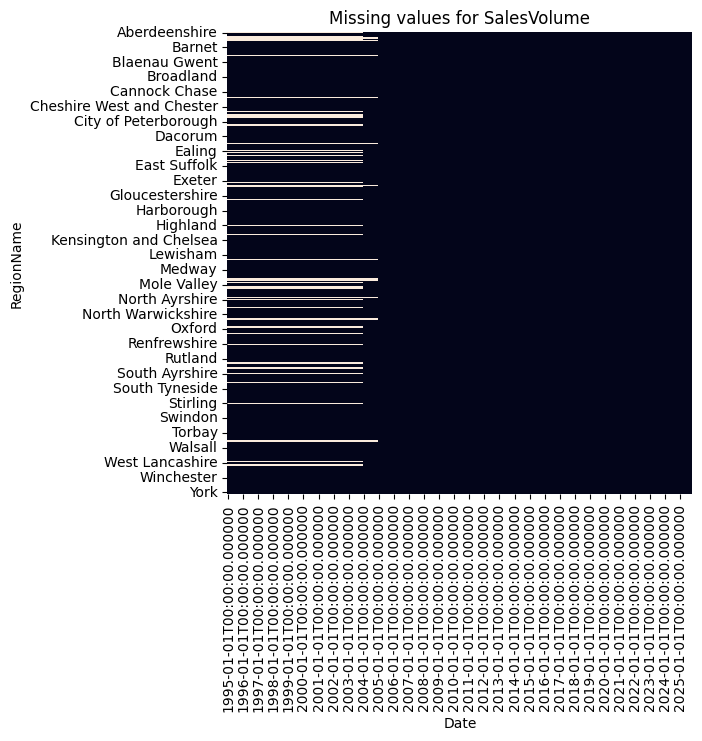

In [69]:
piv_tab_1m = data.pivot_table(values='1m%Change',index='RegionName',columns='Date')
piv_tab_12m = data.pivot_table(values='12m%Change',index='RegionName',columns='Date')
piv_tab_SV = data.pivot_table(values='SalesVolume',index='RegionName',columns='Date')

piv_tabs = [("1m%Change",piv_tab_1m), ("12m%Change", piv_tab_12m), ("SalesVolume", piv_tab_SV)]

def plot_piv_tab_heatmap(piv_tab):
    plt.figure(figsize=(6,6))
    
    sns.heatmap(piv_tab[1].isna(),cbar=False)
    plt.title(f"Missing values for {piv_tab[0]}")
    plt.show()

for pt in piv_tabs:
    plot_piv_tab_heatmap(pt)

It seems like the missing values all occur prior to 2005.

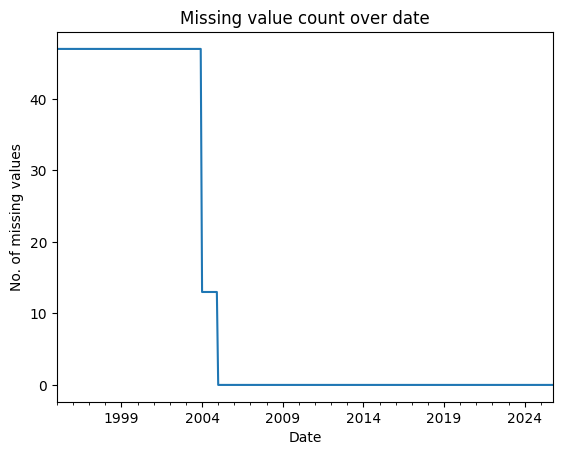

In [70]:
missing_values = piv_tab_SV.isna().sum()
missing_values.plot()
plt.ylabel("No. of missing values")
plt.title("Missing value count over date")
plt.show()

In [71]:
print("Number of missing values 2004",missing_values.loc['2004'].mean())
print("Number of missing values 2005",missing_values.loc['2005'].mean())
print("Number of missing values 2006",missing_values.loc['2006'].mean())

Number of missing values 2004 13.0
Number of missing values 2005 0.0
Number of missing values 2006 0.0


__The dataset exhibits structural missingness prior to 2006, so I restrict analysis to a fully observed balanced panel from 2005 onward.__

In [72]:
data = data[data['Date']>='2006']
data.sort_values(by=['RegionName','Date'])
data.info()

<class 'pandas.DataFrame'>
Index: 97200 entries, 24 to 149084
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          97200 non-null  datetime64[us]
 1   RegionName    97200 non-null  str           
 2   AreaCode      97200 non-null  str           
 3   AveragePrice  97200 non-null  int64         
 4   Index         97200 non-null  float64       
 5   1m%Change     97200 non-null  float64       
 6   12m%Change    97200 non-null  float64       
 7   SalesVolume   96390 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(2)
memory usage: 6.7 MB


There still are some missing values in SalesVolume though...

In [73]:
missing_vals_SV = data[data['SalesVolume'].isnull()].index
data_mv = data.loc[missing_vals_SV]
data_mv

,Date,RegionName,AreaCode,AveragePrice,Index,1m%Change,12m%Change,SalesVolume
262,2025-11-01,Aberdeenshire,S12000034,201555,97.9,-0.8,-0.8,NaN
263,2025-12-01,Aberdeenshire,S12000034,202362,98.3,0.4,0.3,NaN
634,2025-11-01,Adur,E07000223,372499,98.8,-0.6,0.1,NaN
635,2025-12-01,Adur,E07000223,370708,98.3,-0.5,-0.5,NaN
1006,2025-11-01,Amber Valley,E07000032,238246,107.3,0.0,7.2,NaN
...,...,...,...,...,...,...,...,...
148019,2025-12-01,Wyre Forest,E07000239,234081,102.0,0.3,1.0,NaN
148390,2025-11-01,York,E06000014,303055,98.6,-0.5,-0.9,NaN
148391,2025-12-01,York,E06000014,306571,99.7,1.2,0.3,NaN
149083,2025-11-01,Yorkshire and The Humber,E12000003,209467,109.3,1.5,3.8,NaN


In [74]:
missing_dates_SV = data_mv['Date'].unique()
missing_dates_SV

<DatetimeArray>
['2025-11-01 00:00:00', '2025-12-01 00:00:00']
Length: 2, dtype: datetime64[us]

OK so it seems like there are some missing SalesVolume data for the last 2 months. There's 810 missing SalesVolume entries across 2 dates.
Is this all of the SalesVolume for those dates, or just some?

In [75]:
print(data[data['Date']==missing_dates_SV[0]].shape)
print(data[data['Date']==missing_dates_SV[1]].shape)

(405, 8)
(405, 8)


It's all the SalesVolume entries across the whole dataset for those dates. Let's restrict the dataset to not include these dates.

In [76]:
data = data[data['Date'] < missing_dates_SV[0]]
data.info()

<class 'pandas.DataFrame'>
Index: 96390 entries, 24 to 149082
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          96390 non-null  datetime64[us]
 1   RegionName    96390 non-null  str           
 2   AreaCode      96390 non-null  str           
 3   AveragePrice  96390 non-null  int64         
 4   Index         96390 non-null  float64       
 5   1m%Change     96390 non-null  float64       
 6   12m%Change    96390 non-null  float64       
 7   SalesVolume   96390 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(2)
memory usage: 6.6 MB


__Now we have a reduced dataset from Jan 2006- Oct 2025 with no missing values.__ 

#### Add regions
There is a dataset that maps RegionName to a larger region, i.e, South East England, North West England etc. Add this data to our dataset so we can analyse by region.

In [77]:
county_to_region = pd.read_csv("../data/full_counties_to_regions.csv")
county_to_region.head()

,RegionName,Region
0,Guernsey,Crown Dependencies
1,IOM,Crown Dependencies
2,Jersey,Crown Dependencies
3,North East Derbyshire,East Midlands
4,Amber Valley,East Midlands


In [78]:
data = data.merge(county_to_region, on='RegionName',how='left')
data.head()

,Date,RegionName,AreaCode,AveragePrice,Index,1m%Change,12m%Change,SalesVolume,Region
0,2006-01-01,Aberdeenshire,S12000034,115365,56.1,-3.9,9.4,395.0,Scotland
1,2006-02-01,Aberdeenshire,S12000034,113497,55.2,-1.6,12.2,336.0,Scotland
2,2006-03-01,Aberdeenshire,S12000034,115572,56.2,1.8,17.7,471.0,Scotland
3,2006-04-01,Aberdeenshire,S12000034,123601,60.1,6.9,24.5,451.0,Scotland
4,2006-05-01,Aberdeenshire,S12000034,131356,63.8,6.3,24.6,495.0,Scotland


## 4. EDA

### Explore average prices
Make pivot table on average prices.

In [79]:
average_prices = data.pivot_table(index='RegionName',columns='Date',values='AveragePrice')
average_prices

Date,2006-01-01,2006-02-01,2006-03-01,2006-04-01,2006-05-01,2006-06-01,2006-07-01,2006-08-01,2006-09-01,2006-10-01,...,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01
RegionName,,,,,,,,,,,,,,,,,,,,,
Aberdeenshire,115365.0,113497.0,115572.0,123601.0,131356.0,133753.0,134091.0,136731.0,142700.0,145498.0,...,200277.0,194567.0,193731.0,193159.0,196734.0,200115.0,201317.0,202951.0,201831.0,203136.0
Adur,182337.0,184127.0,183639.0,185509.0,188194.0,187572.0,193434.0,192827.0,198908.0,198079.0,...,372876.0,372731.0,372721.0,373551.0,376763.0,382977.0,378576.0,381370.0,382180.0,374865.0
Amber Valley,125833.0,126285.0,128074.0,127900.0,132261.0,132046.0,132329.0,133813.0,134123.0,138133.0,...,222238.0,224456.0,224300.0,223602.0,224311.0,224192.0,226413.0,230680.0,235285.0,238335.0
Angus,91598.0,94637.0,95274.0,97527.0,99629.0,104773.0,109178.0,111687.0,113258.0,113508.0,...,164314.0,165537.0,165304.0,166294.0,168141.0,170387.0,170632.0,167862.0,165145.0,167542.0
Antrim and Newtownabbey,122114.0,122114.0,122114.0,133693.0,133693.0,133693.0,150090.0,150090.0,150090.0,168985.0,...,189792.0,189792.0,189792.0,189463.0,189463.0,189463.0,195765.0,195765.0,195765.0,197918.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wychavon,194648.0,199781.0,200069.0,205287.0,204349.0,207064.0,203846.0,205702.0,205862.0,206028.0,...,311930.0,316813.0,322202.0,317768.0,312704.0,314726.0,324802.0,330999.0,333782.0,331721.0
Wyre,137462.0,139481.0,138098.0,141765.0,144554.0,148967.0,151190.0,149748.0,149886.0,149473.0,...,185964.0,187133.0,191156.0,186363.0,183547.0,178896.0,183701.0,187061.0,188731.0,187052.0
Wyre Forest,141746.0,142804.0,143273.0,146957.0,147892.0,149849.0,152201.0,154124.0,152006.0,151909.0,...,231746.0,229242.0,232425.0,229063.0,229142.0,229485.0,236782.0,238175.0,236339.0,235202.0


In [80]:
max_prices_per_county = average_prices.T.max().sort_values(ascending=False)
max_prices_per_county[:5]

RegionName
Kensington and Chelsea    1656986.0
City of Westminster       1224972.0
City of London            1021539.0
Camden                     948480.0
Hammersmith and Fulham     889834.0
dtype: float64

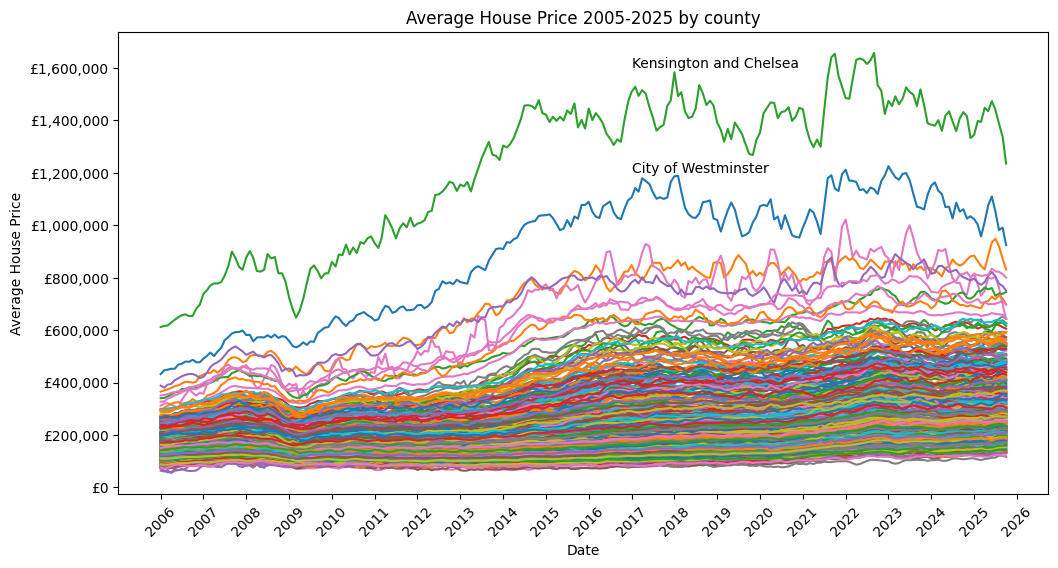

In [81]:
fig,ax = plt.subplots(figsize=(12,6))

ax.plot(average_prices.T)

ax.set_ylabel('Average House Price')
ax.set_xlabel('Date')
ax.set_title('Average House Price 2005-2025 by county')
ax.ticklabel_format(style='plain',axis='y')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.tick_params(axis='x',rotation=45)
ax.annotate('Kensington and Chelsea',xy=(pd.Timestamp('2017'),1600000))
ax.annotate('City of Westminster',xy=(pd.Timestamp('2017'),1200000))

plt.show()

Split into regions and plot

### Explore index
Make a pivot table on indexes and explore.
First let's normalise the index.

In [82]:
data['norm_index'] = data.groupby('RegionName')['Index'].transform(lambda x:x/x.iloc[0]*100)
data.head()

,Date,RegionName,AreaCode,AveragePrice,Index,1m%Change,12m%Change,SalesVolume,Region,norm_index
0,2006-01-01,Aberdeenshire,S12000034,115365,56.1,-3.9,9.4,395.0,Scotland,100.000000
1,2006-02-01,Aberdeenshire,S12000034,113497,55.2,-1.6,12.2,336.0,Scotland,98.395722
2,2006-03-01,Aberdeenshire,S12000034,115572,56.2,1.8,17.7,471.0,Scotland,100.178253
3,2006-04-01,Aberdeenshire,S12000034,123601,60.1,6.9,24.5,451.0,Scotland,107.130125
4,2006-05-01,Aberdeenshire,S12000034,131356,63.8,6.3,24.6,495.0,Scotland,113.725490


In [83]:
norm_indices = data.pivot_table(index='RegionName',columns='Date',values='norm_index')
norm_indices.head()

Date,2006-01-01,2006-02-01,2006-03-01,2006-04-01,2006-05-01,2006-06-01,2006-07-01,2006-08-01,2006-09-01,2006-10-01,...,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01
RegionName,,,,,,,,,,,,,,,,,,,,,
Aberdeenshire,100.0,98.395722,100.178253,107.130125,113.725490,115.864528,116.221034,118.360071,123.529412,126.024955,...,173.440285,168.449198,167.736185,167.379679,170.409982,173.262032,174.331551,175.757576,174.866310,175.935829
Adur,100.0,100.826446,100.619835,101.652893,103.099174,102.892562,105.991736,105.785124,109.090909,108.471074,...,204.338843,204.338843,204.338843,204.752066,206.404959,209.917355,207.438017,209.090909,209.504132,205.371901
Amber Valley,100.0,100.352734,101.763668,101.587302,105.114638,104.938272,105.114638,106.349206,106.525573,109.700176,...,176.543210,178.306878,178.130511,177.601411,178.130511,178.130511,179.894180,183.245150,186.948854,189.417989
Angus,100.0,103.339192,104.042179,106.502636,108.787346,114.411248,119.156415,121.792619,123.550088,123.901582,...,179.261863,180.667838,180.316344,181.546573,183.479789,185.940246,186.115993,183.128295,180.140598,182.776801
Antrim and Newtownabbey,100.0,100.000000,100.000000,109.375000,109.375000,109.375000,122.826087,122.826087,122.826087,138.315217,...,155.298913,155.298913,155.298913,155.027174,155.027174,155.027174,160.190217,160.190217,160.190217,161.956522


In [84]:
max_norm_indices_per_county = norm_indices.T.max().sort_values(ascending=False)
max_norm_indices_per_county[:5]

RegionName
Shetland Islands          350.473186
City of London            326.815642
Orkney Islands            292.248062
City of Westminster       283.286119
Kensington and Chelsea    270.843373
dtype: float64

#### Find average normalised index

In [85]:
mean_norm_index = data.groupby('Date')['norm_index'].mean()

#### Plot normalised index over time

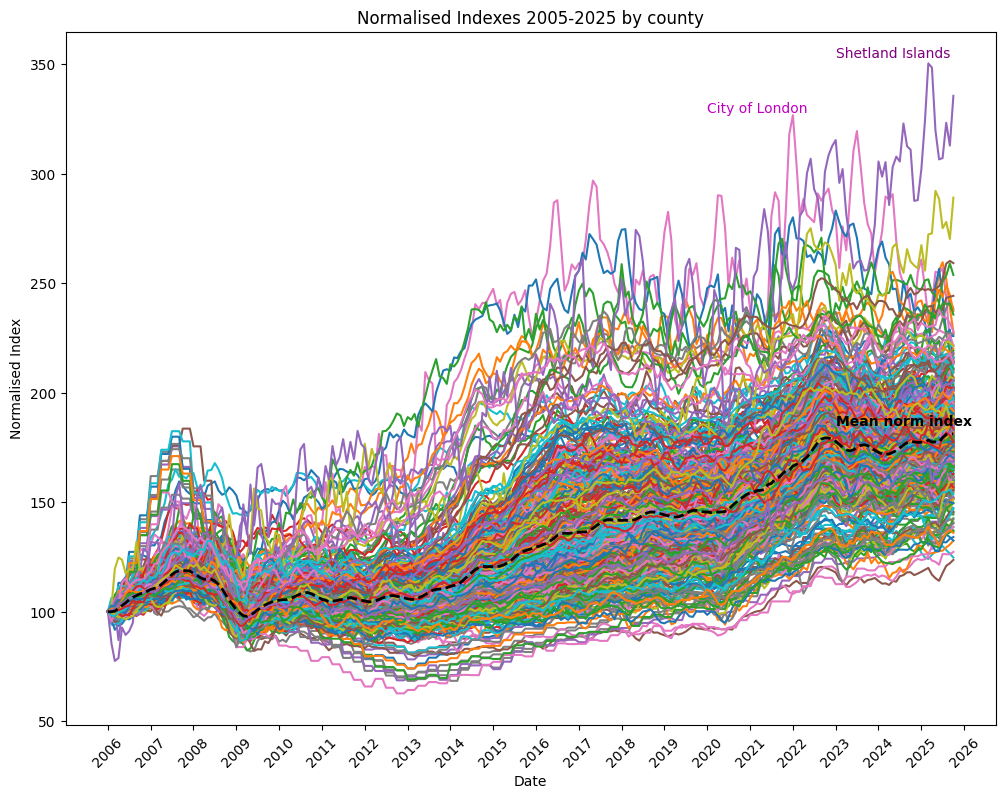

In [86]:
fig,ax = plt.subplots(figsize=(12,9))

ax.plot(norm_indices.T)

ax.set_ylabel('Normalised Index')
ax.set_xlabel('Date')
ax.set_title('Normalised Indexes 2005-2025 by county')
ax.ticklabel_format(style='plain',axis='y')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.tick_params(axis='x',rotation=45)
ax.annotate('Shetland Islands',xy=(pd.Timestamp('2023'),353),c='purple')
ax.annotate('City of London',xy=(pd.Timestamp('2020'),328),c='m')

ax.plot(mean_norm_index.index,mean_norm_index.values,color='black',linewidth=2,linestyle='--')
ax.annotate('Mean norm index',xy=(pd.Timestamp('2023'),185),c='black',fontweight='bold')

plt.show()

In [87]:
region_piv_tab = data.pivot_table(index='Region',columns='Date',values='norm_index',aggfunc='mean')
region_piv_tab.head()

Date,2006-01-01,2006-02-01,2006-03-01,2006-04-01,2006-05-01,2006-06-01,2006-07-01,2006-08-01,2006-09-01,2006-10-01,...,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01
Region,,,,,,,,,,,,,,,,,,,,,
East Midlands,100.0,99.599383,99.543170,100.406485,101.406082,102.561311,103.564847,104.616845,104.875395,105.034633,...,171.280398,171.548660,172.220033,170.386610,170.203094,169.334417,171.780972,173.634085,174.817292,175.395376
East of England,100.0,100.146051,100.459602,101.234700,102.401759,103.171971,104.291773,105.336396,106.436157,107.007331,...,187.881348,187.946023,188.820650,187.455803,187.552424,187.680449,189.908510,191.300719,191.638012,192.316194
London,100.0,100.471778,100.918627,101.626509,102.669072,103.926839,105.520212,107.078540,108.145442,108.659738,...,220.791694,220.162754,219.119696,219.991269,221.220425,222.492602,222.756553,221.977263,220.428250,216.591268
North East England,100.0,99.138537,99.440472,100.841154,102.585524,103.921874,105.002252,105.587171,106.509219,107.018889,...,134.452260,134.837734,136.689645,134.871716,134.726120,134.182531,136.680091,138.584608,139.109020,139.686700
North West England,100.0,100.330309,99.918181,101.427390,102.626577,104.477248,105.433427,106.496459,107.192296,107.653025,...,166.184096,166.536814,168.743835,166.558737,166.526330,165.451671,168.776348,170.939502,171.528817,171.827051


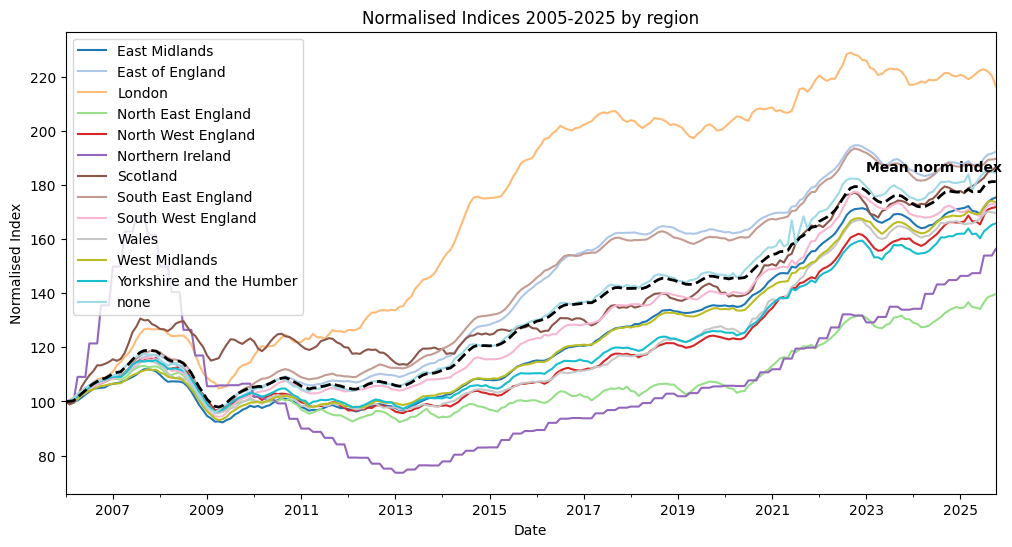

In [88]:
fig,ax = plt.subplots(figsize=(12,6))

region_piv_tab.T.plot(ax=ax,colormap='tab20')

ax.set_ylabel('Normalised Index')
ax.set_xlabel('Date')
ax.set_title('Normalised Indices 2005-2025 by region')
ax.ticklabel_format(style='plain',axis='y')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis='x',rotation=45)
ax.legend(fontsize=8)

mean_norm_index.plot(color='black',linewidth=2,linestyle='--')
ax.annotate('Mean norm index',xy=(pd.Timestamp('2023'),185),c='black',fontweight='bold')

plt.show()

By inspection we can see that London has experienced the most growth with East of England and South East of England following a similar trend at a reduced scale. Northern Ireland does not appear to follow the same pattern, the North East experiences the least growth. In general with teh exception of Scotland, Northern Ireland and the North East house prices appear to have fallen from a peak in mid 2022.

### Add rolling means

Before analysis let's add some useful features. We already have MoM change (1m%Change) and YoY change(12m%Change), but let's add some rolling averages for index and YoY change.

In [89]:
# create 3 month rolling mean for growth
data['YoYRolling3'] = data['12m%Change'].rolling(window=3).mean()

# create 12 month rolling mean for index
data['IndexRolling12'] = data['norm_index'].rolling(window=12).mean()

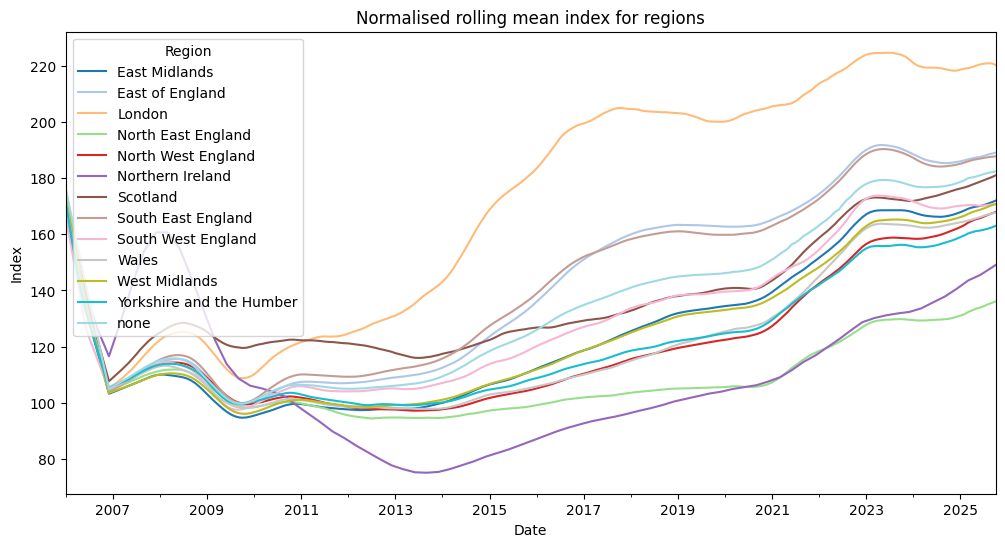

In [90]:
rolling_idx_piv_tab = data.pivot_table(index='Region',columns='Date',values='IndexRolling12',aggfunc='mean')

fig,ax = plt.subplots(figsize = (12,6))
rolling_idx_piv_tab.T.plot(ax=ax,colormap='tab20')
plt.title('Normalised rolling mean index for regions')
plt.ylabel('Index')
plt.show()


#### Spread of indices

In [91]:
std_norm_index = data.groupby('Date')['norm_index'].std()

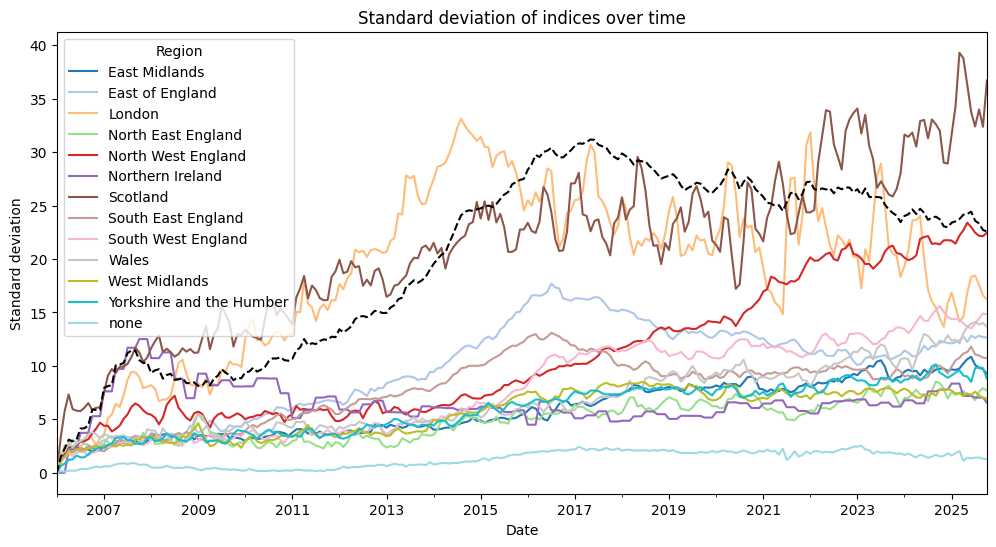

In [92]:
vol_region_tab = data.pivot_table(index='Region',columns='Date',values='norm_index',aggfunc='std')

fig,ax = plt.subplots(figsize=(12,6))
vol_region_tab.T.plot(ax=ax,colormap='tab20')
std_norm_index.plot(linestyle='--',color='black')
plt.ylabel("Standard deviation")
plt.title("Standard deviation of indices over time")
plt.show()

### Growth analysis

Investigating 12m% change over time.

In [93]:
region_piv_tab_12m = data.pivot_table(index='Region',columns='Date',values='12m%Change',aggfunc='mean')
region_piv_tab_12m.head()

Date,2006-01-01,2006-02-01,2006-03-01,2006-04-01,2006-05-01,2006-06-01,2006-07-01,2006-08-01,2006-09-01,2006-10-01,...,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01
Region,,,,,,,,,,,,,,,,,,,,,
East Midlands,4.017778,4.142222,4.228889,3.817778,3.726667,4.231111,4.606667,5.175556,5.024444,4.940000,...,3.222222,4.162222,5.035556,3.742222,3.073333,2.417778,3.153333,3.737778,3.460000,3.257778
East of England,1.813208,2.688679,3.228302,4.245283,4.494340,4.500000,4.716981,5.539623,6.367925,7.052830,...,1.400000,1.975472,2.773585,2.233962,2.124528,1.833962,2.564151,2.716981,2.090566,2.107547
London,2.505405,4.143243,4.100000,4.105405,4.643243,5.745946,6.986486,7.721622,8.497297,9.094595,...,1.851351,1.527027,0.937838,1.540541,1.418919,1.862162,1.772973,0.859459,-0.397297,-2.086486
North East England,10.542857,9.735714,10.307143,10.735714,9.971429,9.178571,8.242857,7.064286,7.500000,8.028571,...,4.157143,4.785714,7.264286,5.750000,5.264286,3.900000,5.057143,5.671429,4.942857,4.650000
North West England,9.097500,10.172500,9.445000,9.940000,8.822500,8.757500,8.117500,8.097500,8.075000,8.302500,...,4.590000,5.292500,7.112500,5.180000,4.340000,2.977500,4.297500,4.517500,3.880000,3.302500


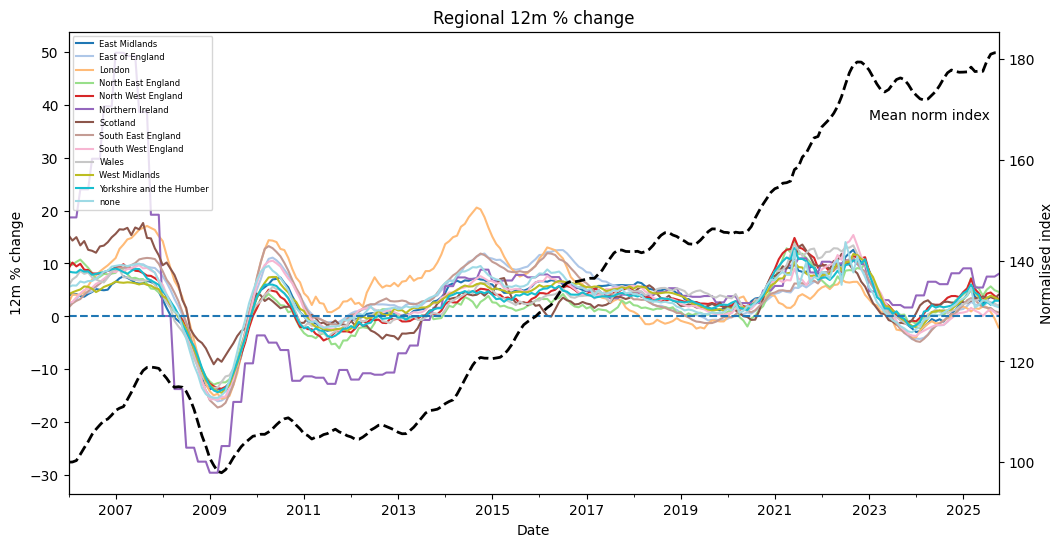

In [94]:
fig,ax = plt.subplots(figsize=(12,6))
region_piv_tab_12m.T.plot(ax=ax,colormap='tab20')
plt.axhline(y=0, linestyle='--') 
plt.ylabel("12m % change")
plt.title("Regional 12m % change")
ax.legend(fontsize=6,loc='upper left')

ax2 = ax.twinx()
ax2.set_ylabel("Normalised index")
mean_norm_index.plot(color='black',linewidth=2,linestyle='--')
ax2.annotate('Mean norm index',xy=(pd.Timestamp('2023'),168),c='black')



plt.show()


12 month % growth is steady for many regions in England until late 2007, then drops heavily into negative growth from late 2008 to 2010. Growth looks more stable from 2011 through to 2020, seeming to trend slightly downwards towards 2020, before entering another period of volatility through to end of 2025.  

Northern Ireland demonstrates the greatest volatility especially over the period 2006-2014. London also demonstrates more volatily over the same period. Both Northern Ireland and London show less volality over the second turbulent period 2020-2025.

Growth across regions diverges less from 2015 onwards, although Northern Ireland appears to not dip quite as strongly in growth post 2023.


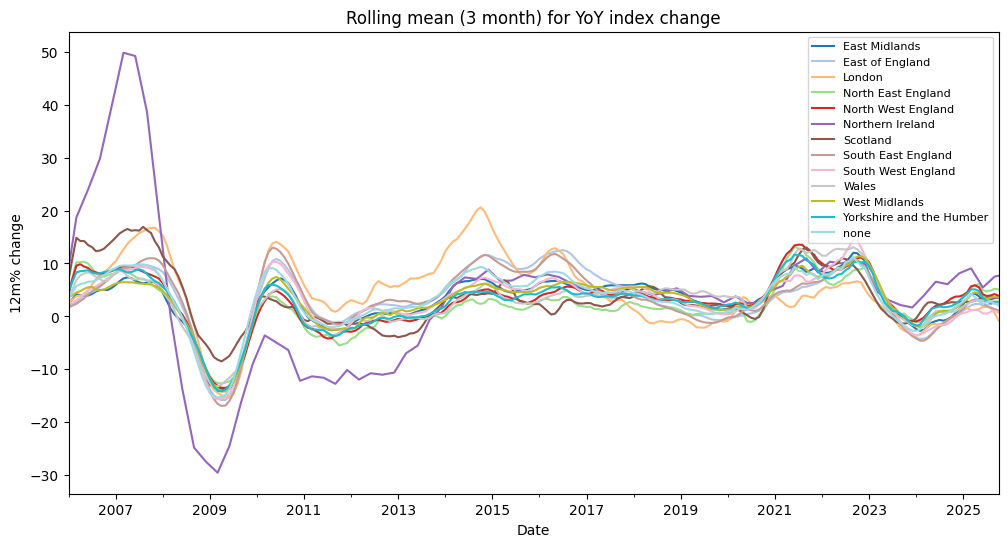

In [95]:
rolling_piv_tab_12m = data.pivot_table(index='Region',columns='Date',values='YoYRolling3',aggfunc='mean')
fig,ax = plt.subplots(figsize=(12,6))
rolling_piv_tab_12m.T.plot(ax=ax,colormap='tab20')
plt.ylabel('12m% change')
ax.legend(fontsize=8)
plt.title('Rolling mean (3 month) for YoY index change')

plt.show()

### Growth volatility over 6 month rolling window

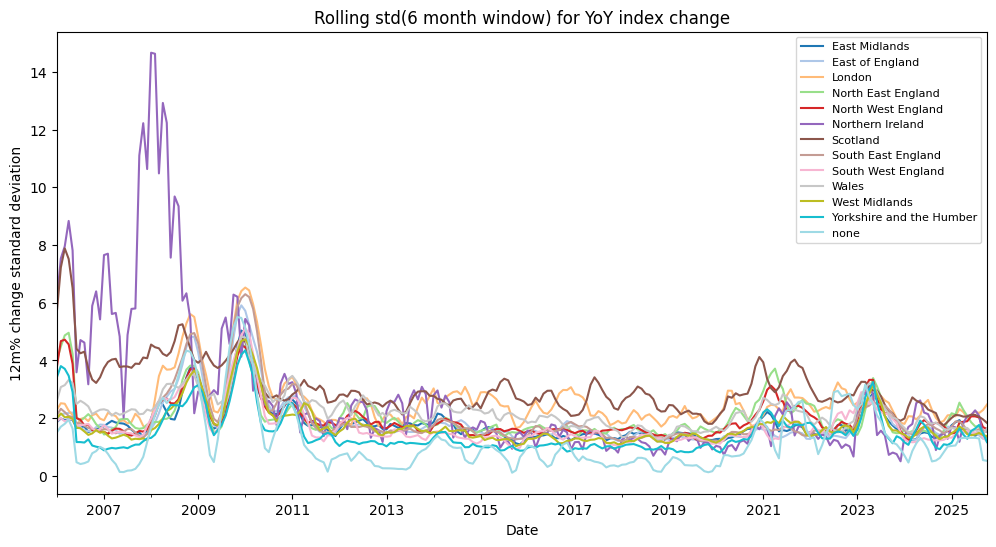

In [96]:
data['YoYRollingStd6']= data['12m%Change'].rolling(6).std()

rolling_std_growth = data.pivot_table(index='Region',columns='Date',values='YoYRollingStd6',aggfunc='mean')
fig,ax = plt.subplots(figsize=(12,6))
rolling_std_growth.T.plot(ax=ax,colormap='tab20')
plt.ylabel('12m% change standard deviation')
ax.legend(fontsize=8)
plt.title('Rolling std(6 month window) for YoY index change')

plt.show()


As seen in the index plots for region, Northern Ireland experienced the most volatility around the 2007-2008 financial crisis, as well as Scotland and London. Volatility through Covid was considerably less for most regions.

#### Some observations

- Northern Ireland exhibits significantly higher volatility in price growth during 2006–2014, followed by a more stable growth pattern post-2014, with relatively steady increases from 2020–2025 compared to other regions.
- Cross-regional dispersion increases up to around 2017, before declining steadily towards 2025, suggesting partial convergence in regional price dynamics.
- London consistently shows the highest normalised index levels, followed by the East and South East of England, while the North East remains the lowest within England.
- Since 2022, several regions (notably London, East, and South East England) show flat or declining indices, while regions such as Yorkshire and the Midlands continue to exhibit modest growth.
- Regional trends are broadly similar across England, with Northern Ireland behaving as a relative outlier, particularly in earlier periods.

#### Implications for Modelling

- The presence of differing volatility regimes suggests that models may benefit from region-specific features or interactions.
- Broad similarity in regional trends indicates shared macro drivers, supporting the inclusion of common temporal features (e.g. lagged growth).
- Divergence in recent trends (post-2022) suggests that more recent data may carry stronger predictive signal than older periods.
- Northern Ireland’s distinct behaviour may require separate treatment or careful evaluation to avoid degrading model performance.

## 4. Feature Engineering
Add:
Lag 1 month, 3 month, 12 month, region dummies
Inflation, unemployment, interest rates

momentum -> lagged growth, trend -> rolling mean, risk-> rolling std, demand -> sales volume, structure -> region dummies, seasonality-> month/quarter


In [97]:
data.head()

,Date,RegionName,AreaCode,AveragePrice,Index,1m%Change,12m%Change,SalesVolume,Region,norm_index,YoYRolling3,IndexRolling12,YoYRollingStd6
0,2006-01-01,Aberdeenshire,S12000034,115365,56.1,-3.9,9.4,395.0,Scotland,100.000000,NaN,NaN,NaN
1,2006-02-01,Aberdeenshire,S12000034,113497,55.2,-1.6,12.2,336.0,Scotland,98.395722,NaN,NaN,NaN
2,2006-03-01,Aberdeenshire,S12000034,115572,56.2,1.8,17.7,471.0,Scotland,100.178253,13.100000,NaN,NaN
3,2006-04-01,Aberdeenshire,S12000034,123601,60.1,6.9,24.5,451.0,Scotland,107.130125,18.133333,NaN,NaN
4,2006-05-01,Aberdeenshire,S12000034,131356,63.8,6.3,24.6,495.0,Scotland,113.725490,22.266667,NaN,NaN


#### Add index growth lags

In [54]:
data['lag1'] = data['12m%Change'].shift(1)
data['lag3'] = data['12m%Change'].shift(3)
data['lag12'] = data['12m%Change'].shift(12)


#### Add sales volume lags and growth

In [100]:
data["vol_lag_1"] = data["SalesVolume"].shift(1)
data["vol_lag_12"] = data["SalesVolume"].shift(12)
data["vol_6mChange"] = data["SalesVolume"].pct_change(6)

#### Add region dummies
One-hot encode the categorical variable region.

In [50]:
dummies = pd.get_dummies(data['Region'],drop_first=True)
data = pd.concat([data,dummies],axis=1)